# Fig 1.07

Collins toggle switch

For Figures 1.7, 7.13, 7.14, 7.15

In [1]:
using OrdinaryDiffEq
using ModelingToolkit
using Plots
Plots.default(linewidth=2)

Convenience functions

In [2]:
hil(x, k) = x / (x + k)
hil(x, k, n) = hil(x^n, k^n)

hil (generic function with 2 methods)

Define the problem

In [3]:
function build_collins(;name)
    @parameters begin
        a1=3.0
        a2=2.5
        β=4.0
        γ=4.0
    end

    @independent_variables t
    @variables begin
        s1(t)=0.075
        s2(t)=2.5
        i1(t)
        i2(t)
    end

    D = Differential(t)

    eqs = [
        D(s1) ~ a1 * hil(1 + i2, s2, β) - s1,
        D(s2) ~ a2 * hil(1 + i1, s1, γ) - s2,
        i2 ~ 10 * (10 < t) * (t < 20),
        i1 ~ 10 * (30 < t) * (t < 40),
    ]
    return ODESystem(eqs, t; name)
end

build_collins (generic function with 1 method)

In [4]:
@mtkbuild sys = build_collins()

Model sys:
Equations (2):
  2 standard: see equations(sys)
Unknowns (2): see unknowns(sys)
  s1(t) [defaults to 0.075]
  s2(t) [defaults to 2.5]
Parameters (4): see parameters(sys)
  β [defaults to 4.0]
  a2 [defaults to 2.5]
  γ [defaults to 4.0]
  a1 [defaults to 3.0]
Observed (2): see observed(sys)

Solve the problem

In [5]:
tspan = (0.0, 50.0)
prob = ODEProblem(sys, [], tspan, [])
sol = solve(prob, tstops=10:10:40)

retcode: Success
Interpolation: 3rd order Hermite
t: 51-element Vector{Float64}:
  0.0
  0.38548049109061366
  1.2786313586853497
  2.464538731594535
  4.06089298356771
  6.199065127274195
  9.163107137014421
 10.0
 10.237564173675388
 10.345905622741512
  ⋮
 36.914997164885754
 37.93079710385752
 39.07484274669089
 40.0
 41.178943649875706
 42.81986325559389
 44.70418578722446
 47.243347624826804
 50.0
u: 51-element Vector{Vector{Float64}}:
 [0.075, 2.5]
 [0.07496310584167311, 2.4999747263084027]
 [0.07491895384143081, 2.499943104158718]
 [0.07489947360105878, 2.499927975740838]
 [0.07489347508722309, 2.4999227222886917]
 [0.07489238103870029, 2.499921565722204]
 [0.0748923054927769, 2.4999214349680665]
 [0.07489223296465887, 2.4999213893330796]
 [0.6391346146761681, 2.3721192115081546]
 [0.8809050681389734, 2.319140246326736]
 ⋮
 [0.08211174811519016, 2.4974663084645288]
 [0.07761093651936421, 2.4990818963098618]
 [0.07579211279532862, 2.499707057292954]
 [0.07525607577666808, 2.4997

Visual

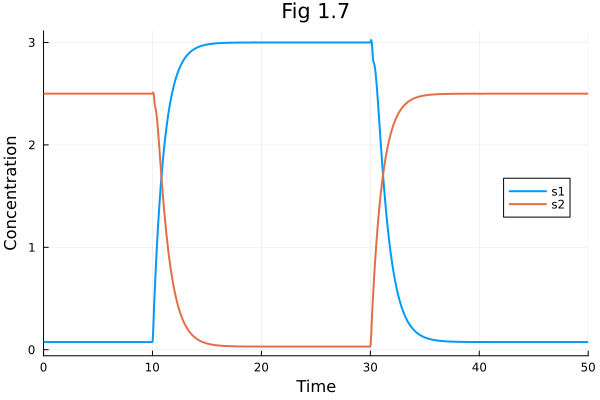

In [6]:
plot(sol, legend=:right, xlabel = "Time", ylabel="Concentration", title="Fig 1.7")

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*